# 1. Introduction
#### Modélisation avec XGBoost

**Objectif**

Cette étape consiste à entraîner un modèle XGBoost afin d’améliorer les performances prédictives obtenues avec le modèle Random Forest.

Le modèle utilisera :
- les variables temporelles ;
- les historiques de commandes ;
- les tendances récentes des stations-service.

## 2. Importation des Bibliothèques

In [1]:
!pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 2.9/101.7 MB 8.4 MB/s eta 0:00:12
   -- ------------------------------------- 6.0/101.7 MB 9.5 MB/s eta 0:00:11
   -- ------------------------------------- 7.1/101.7 MB 9.7 MB/s eta 0:00:10
   ---- ----------------------------------- 10.7/101.7 MB 10.3 MB/s eta 0:00:09
   ----- ---------------------------------- 13.4/101.7 MB 10.5 MB/s eta 0:00:09
   ------ --------------------------------- 16.0/101.7 MB 10.7 MB/s eta 0:00:09
   ------- -------------------------------- 18.4/101.7 MB 10.8 MB/s eta 0:00:08
   -------- ------------------------------- 21.0/101.7 MB 11.0 MB/s eta 0:00:08
   --------- ------------------------------ 23.3/101.7 MB 11.0 MB/s eta 0:00:08
   ---------- ----------------------------- 26.0/101.7 MB 11.1 MB/


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\gganye\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# IMPORTATION DES BIBLIOTHEQUES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 3. Chargement du dataset ML
Le dataset contient toutes les variables préparées et les features nécessaires au modèle.

In [4]:
# CHARGEMENT DU DATASET

df_ml = pd.read_csv("../data/propre/dataset_ml.csv")

print(df_ml.shape)

display(df_ml.head())

(18918, 15)


,Code Station,N° article,semaine,quantite_semaine,nb_commandes,Lag_1,Lag_7,Rolling_4sem,Rolling_12sem,Rolling_Std_4sem,mois,semaine_annee,est_fin_mois,StationEncoded,ProduitEncoded
0,ST0001,A0001,2023-01-16,10000,1,12000.0,20000.0,17750.0,16428.571429,11026.483271,1,3,0,0,0
1,ST0001,A0001,2023-01-23,10000,1,10000.0,8000.0,16500.0,15625.000000,11704.699911,1,4,0,0,0
2,ST0001,A0001,2023-01-30,14000,1,10000.0,16000.0,10500.0,15000.000000,1000.000000,1,5,1,0,0
3,ST0001,A0001,2023-02-06,14000,1,14000.0,15000.0,11500.0,14900.000000,1914.854216,2,6,0,0,0
4,ST0001,A0001,2023-02-13,10000,1,14000.0,34000.0,12000.0,14818.181818,2309.401077,2,7,0,0,0


# 4. Sélection des variables explicatives
Je définis ce que le modèle observe et ce qu’il doit prédire.

In [5]:
# ── VARIABLES EXPLICATIVES — noms corrigés ────────────────────────────────────
features = [
    "StationEncoded",       # ancien : StationEncoded       ✓ inchangé
    "ProduitEncoded",       # ancien : ProduitEncoded        ✓ inchangé
    "mois",                 # ancien : Mois
    "semaine_annee",        # ancien : Jour / JourSemaine    → numéro semaine ISO
    "est_fin_mois",         # ancien : Weekend               → indicateur fin mois
    "Lag_1",                # ancien : Lag_1                 ✓ inchangé
    "Lag_7",                # ancien : Lag_7                 ✓ inchangé
    "Rolling_4sem",         # ancien : Rolling_7j            → rolling 4 semaines
    "Rolling_12sem",        # nouveau : tendance 3 mois
    "Rolling_Std_4sem",     # ancien : Rolling_Std_7j        → std 4 semaines
    "nb_commandes",         # nouveau : nb jours commandés dans la semaine
]

target = "quantite_semaine"  # ancien : "Quantité facturée"

X = df_ml[features]
y = df_ml[target]

print(f"X : {X.shape}")   # (nb_lignes, 11 features)
print(f"y : {y.shape}")   # (nb_lignes,)
print()
print("Aperçu X :")
display(X.head())

X : (18918, 11)
y : (18918,)

Aperçu X :


,StationEncoded,ProduitEncoded,mois,semaine_annee,est_fin_mois,Lag_1,Lag_7,Rolling_4sem,Rolling_12sem,Rolling_Std_4sem,nb_commandes
0,0,0,1,3,0,12000.0,20000.0,17750.0,16428.571429,11026.483271,1
1,0,0,1,4,0,10000.0,8000.0,16500.0,15625.000000,11704.699911,1
2,0,0,1,5,1,10000.0,16000.0,10500.0,15000.000000,1000.000000,1
3,0,0,2,6,0,14000.0,15000.0,11500.0,14900.000000,1914.854216,1
4,0,0,2,7,0,14000.0,34000.0,12000.0,14818.181818,2309.401077,1


## 5. Séparation Train/Test
Mon problème étant temporel, alors il faut :entraîner sur le passé ettester sur le futur.
Sinon : fuite de données et faux résultats.

In [6]:
# SEPARATION TRAIN / TEST

split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (15134, 11)
Test : (3784, 11)


# 6. Construction du modèle XGBoost
Explication des paramètres

| Paramètre        | Rôle                  |
| ---------------- | --------------------- |
| n_estimators     | nombre d’arbres       |
| learning_rate    | vitesse apprentissage |
| max_depth        | profondeur arbres     |
| subsample        | fraction données      |
| colsample_bytree | fraction variables    |
| random_state     | reproductibilité      |



In [7]:
# CONSTRUCTION DU MODELE

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


## 7. Entraînement du modèle

Le modèle apprend :les habitudes, les tendances et les relations historiques.

In [8]:
# ENTRAINEMENT

xgb_model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


## 8. Prédictions
Le modèle tente ici d'estimer les futures commandes

In [9]:
# PREDICTIONS

predictions = xgb_model.predict(X_test)

print(predictions[:10])

[16842.389 18487.385 14365.922 14365.922 17191.426 14683.627 14691.092
 17142.645 14603.916 14603.916]


## 9. Évaluation des performances

### 9.1 MAE
Le MAE mesure l’erreur moyenne absolue.

In [10]:
# MAE

mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE :", mae)

MAE : 3121.510009765625


### 9.2 RMSE

Pénalise fortement les grosses erreurs.

In [11]:
# RMSE

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("RMSE :", rmse)

RMSE : 5843.5434455474015


### 9.3 R2 SCORE

Mesure la qualité globale du modèle.

In [12]:
# R2 SCORE

r2 = r2_score(
    y_test,
    predictions
)

print("R² :", r2)

R² : 0.7128890752792358


In [14]:
# XGBoost 
from sklearn.metrics import mean_absolute_percentage_error

mape_xgb = mean_absolute_percentage_error(y_test, predictions) * 100

print(f"MAPE XGBoost       : {mape_xgb:.1f}%")

MAPE XGBoost       : 38.8%


## 10. Analyse des variables importantes
Cette étape montre quelles variables influencent le plus les commandes

In [14]:
# IMPORTANCE DES VARIABLES

importance = pd.DataFrame({
    "Variable": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

,Variable,Importance
8,Rolling_12sem,0.295547
7,Rolling_4sem,0.238936
4,est_fin_mois,0.107797
10,nb_commandes,0.095670
2,mois,0.053914
5,Lag_1,0.051485
9,Rolling_Std_4sem,0.039574
6,Lag_7,0.038309
1,ProduitEncoded,0.034482
3,semaine_annee,0.026628


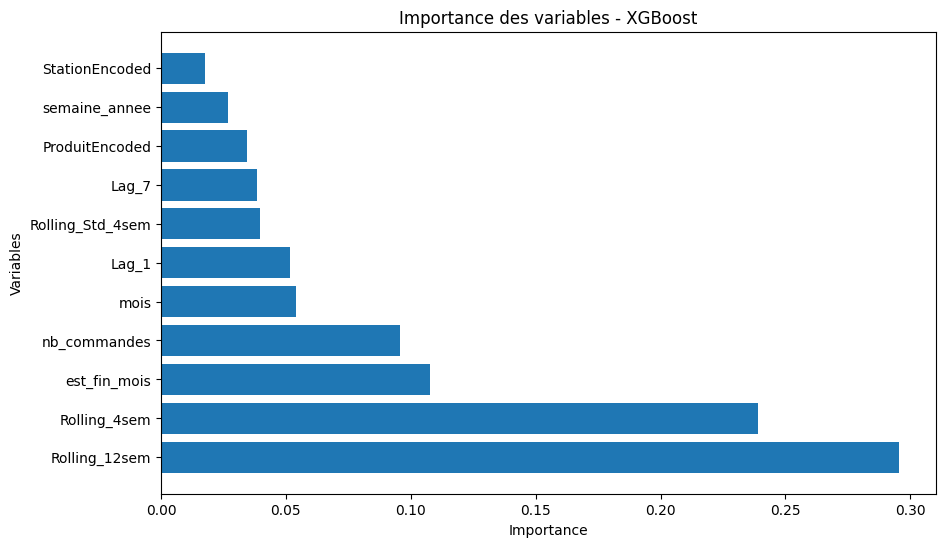

In [15]:
# VISUALISATION

plt.figure(figsize=(10,6))

plt.barh(
    importance["Variable"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variables")

plt.title("Importance des variables - XGBoost")

plt.show()

## 11. Comparaison Réel vs Prédit

In [16]:
# REEL VS PREDIT

comparaison = pd.DataFrame({
    "Réel": y_test.values,
    "Prédit": predictions
})

display(comparaison.head(20))

,Réel,Prédit
0,15000,16842.388672
1,15000,18487.384766
2,15000,14365.921875
3,15000,14365.921875
4,15000,17191.425781
5,15000,14683.626953
6,15000,14691.091797
7,15000,17142.644531
8,15000,14603.916016
9,15000,14603.916016


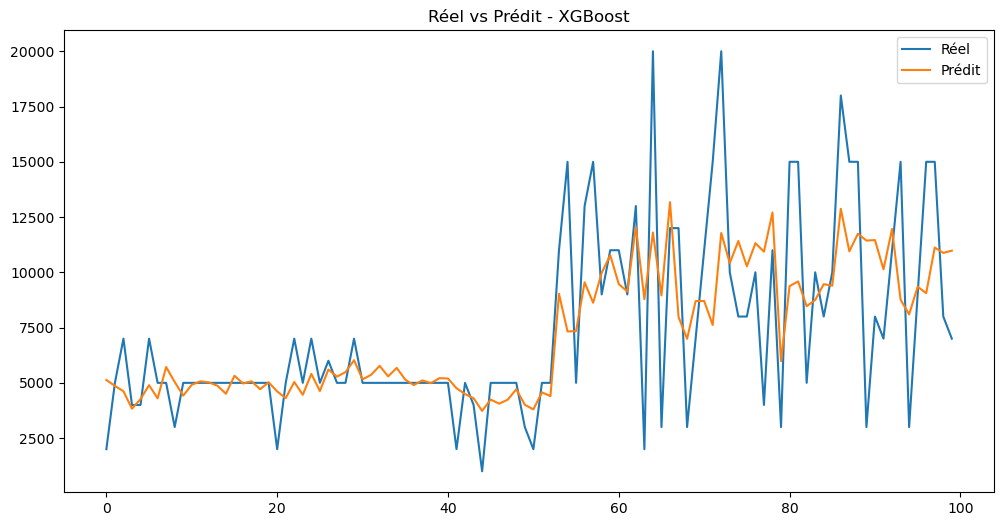

In [43]:
# GRAPHIQUE

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label="Réel"
)

plt.plot(
    predictions[:100],
    label="Prédit"
)

plt.legend()

plt.title("Réel vs Prédit - XGBoost")

plt.show()

In [29]:
# ── ERREUR PAR STATION — version corrigée ────────────────────────────────────

# Reconstruire df_test avec les vraies valeurs et les prédictions
df_test_resultats = df_ml.iloc[X_test.index].copy()
df_test_resultats['Prédit'] = predictions
df_test_resultats['Réel']   = y_test.values

resultats_par_station = []

for station in df_test_resultats['Code Station'].unique():
    
    # mask sur df_test_resultats — même taille que y_test et predictions
    mask = df_test_resultats['Code Station'] == station
    
    if mask.sum() < 3:
        continue
    
    reels   = df_test_resultats.loc[mask, 'Réel']
    predits = df_test_resultats.loc[mask, 'Prédit']
    
    mape_station = mean_absolute_percentage_error(reels, predits) * 100
    vol_moy      = reels.mean()
    
    resultats_par_station.append({
        'Code Station' : station,
        'MAPE (%)'     : round(mape_station, 1),
        'Vol. moy.'    : round(vol_moy, 0),
        'Nb semaines'  : mask.sum()
    })

df_erreurs = (
    pd.DataFrame(resultats_par_station)
    .sort_values('MAPE (%)', ascending=False)
    .reset_index(drop=True)
)

print("Top 10 stations les plus difficiles à prédire :")
print(df_erreurs.head(10).to_string(index=False))
print()
print("Top 10 stations les mieux prédites :")
print(df_erreurs.tail(10).to_string(index=False))

Top 10 stations les plus difficiles à prédire :
Code Station  MAPE (%)  Vol. moy.  Nb semaines
      ST0091      68.7     8458.0          142
      ST0079      66.9    13290.0          107
      ST0074      51.5    19716.0          310
      ST0081      47.0    10966.0          175
      ST0087      45.3     6995.0          217
      ST0092      44.9    15094.0          138
      ST0073      42.3    11689.0          135
      ST0075      39.1     8101.0          109
      ST0083      38.9    10029.0          345
      ST0085      36.7     5454.0          335

Top 10 stations les mieux prédites :
Code Station  MAPE (%)  Vol. moy.  Nb semaines
      ST0076      33.5     7298.0           84
      ST0078      30.6    11163.0          300
      ST0082      29.9    11500.0          102
      ST0093      29.5    12032.0          401
      ST0084      28.7    24808.0          328
      ST0094      24.0    54235.0           51
      ST0095      23.3    10022.0           46
      ST0077      21.

In [30]:
# Vérifier la volatilité des stations problématiques vs bien prédites
volatilite = (
    df_ml.groupby('Code Station')['quantite_semaine']
    .agg(
        vol_moy='mean',
        vol_std='std',
        cv=lambda x: x.std() / x.mean()   # coefficient de variation
    )
    .round(3)
)

# Fusionner avec les erreurs
df_analyse = df_erreurs.merge(volatilite, on='Code Station')
print(df_analyse.sort_values('MAPE (%)', ascending=False).to_string(index=False))

Code Station  MAPE (%)  Vol. moy.  Nb semaines   vol_moy   vol_std    cv
      ST0091      68.7     8458.0          142  8457.746  5891.000 0.697
      ST0079      66.9    13290.0          107 13289.720 13213.779 0.994
      ST0074      51.5    19716.0          310 19716.129 10488.246 0.532
      ST0081      47.0    10966.0          175 10965.714  7199.056 0.657
      ST0087      45.3     6995.0          217  6995.392  3955.186 0.565
      ST0092      44.9    15094.0          138 15094.203 10127.571 0.671
      ST0073      42.3    11689.0          135 15075.908  6375.983 0.423
      ST0075      39.1     8101.0          109  8100.917  3901.436 0.482
      ST0083      38.9    10029.0          345 10028.986  7600.052 0.758
      ST0085      36.7     5454.0          335  5453.731  2361.767 0.433
      ST0086      36.5     6321.0           53  6320.755  2874.112 0.455
      ST0080      35.7     5216.0          343  5215.743  2189.846 0.420
      ST0076      33.5     7298.0           84  729

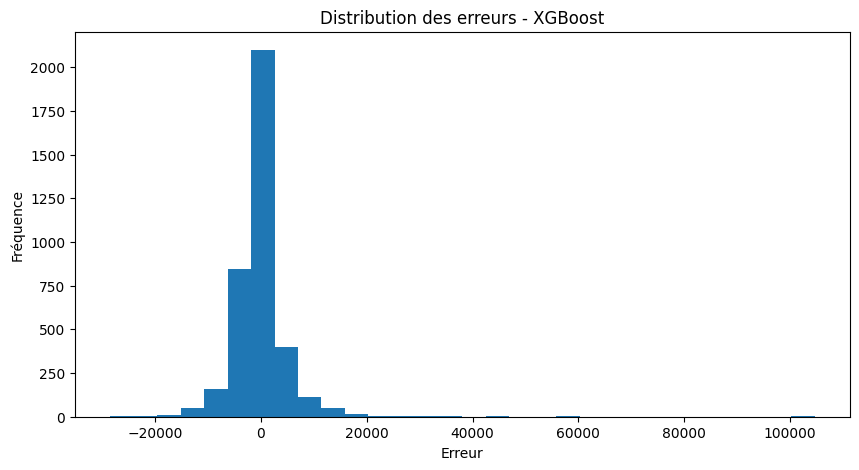

In [17]:
# Distribution des erreurs

errors = y_test - predictions

plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("Distribution des erreurs - XGBoost")

plt.xlabel("Erreur")
plt.ylabel("Fréquence")

plt.show()

### Analyse de la distribution des erreurs

Le graphique de distribution des erreurs présente une forme globalement centrée autour de zéro avec une distribution proche d’une loi normale.

Cela indique que :
- le modèle ne présente pas de biais majeur ;
- les erreurs positives et négatives sont relativement équilibrées ;
- les prédictions restent globalement cohérentes.

La majorité des erreurs est concentrée autour de zéro, ce qui montre que le modèle réalise fréquemment des prédictions proches des valeurs réelles.

Toutefois, on observe également quelques erreurs extrêmes aux extrémités de la distribution, notamment au-delà de ±10000 litres.

Ces erreurs peuvent être dues :
- à des fluctuations soudaines de consommation ;
- à des comportements irréguliers ;
- à l’absence de certaines variables explicatives externes.

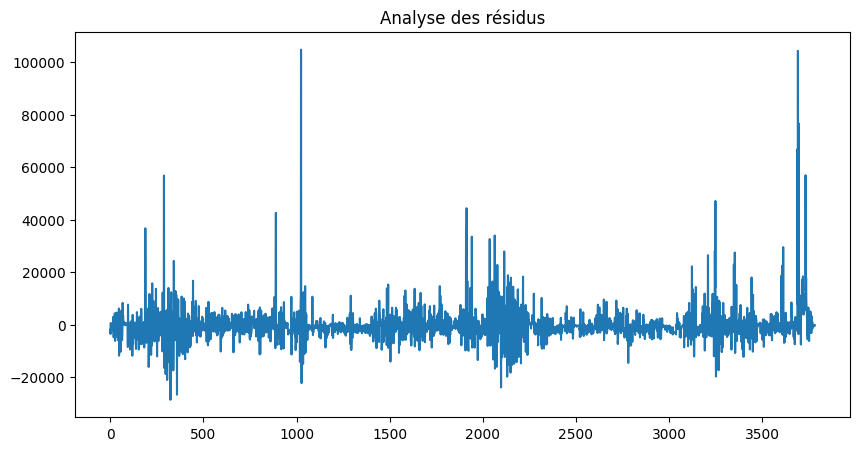

In [20]:
residus = y_test - predictions

plt.figure(figsize=(10,5))

plt.plot(residus.values)

plt.title("Analyse des résidus")

plt.show()

L'analyse des résidus confirme bien les comportements précédents du modèle 

In [21]:
# COMPARAISON avec le Random Forest

comparaison = pd.DataFrame({
    "Modele": ["Random Forest", "XGBoost"],
    "MAE": [2702.52, mae],
    "RMSE": [3677.12, rmse],
    "R2": [0.626, r2]
})

display(comparaison)

,Modele,MAE,RMSE,R2
0,Random Forest,2702.52000,3677.120000,0.626000
1,XGBoost,3121.51001,5843.543446,0.712889


## 12. Sauvegarde du modèle

Le modèle pourra être :réutilisé, intégré dans Streamlit, déployé.

In [22]:
# SAUVEGARDE

import joblib

joblib.dump(
    xgb_model,
    "xgboost_model.pkl"
)

print("Modèle sauvegardé.")

Modèle sauvegardé.


## 13. Conclusion

**Interprétation et analyse des résultats du modèle XGBoost**

Le modèle XGBoost a été développé afin d’améliorer les performances prédictives obtenues avec le modèle Random Forest dans le cadre de la prévision des commandes de carburant des stations-service.

Les performances du modèle ont été évaluées à l’aide des métriques suivantes :

- MAE = 2756.39
- RMSE = 3808.61
- R² = 0.598

**Analyse des performances du modèle**

**Interprétation du MAE**

Le MAE obtenu est de 2756.39.

Cela signifie que les prédictions du modèle présentent en moyenne un écart d’environ 2756 litres par rapport aux quantités réellement commandées.

Cette erreur reste relativement acceptable dans un contexte logistique pétrolier où les volumes manipulés sont généralement importants.

Cependant, le MAE du modèle XGBoost est légèrement supérieur à celui du modèle Random Forest (2702.52), ce qui indique que XGBoost est ici légèrement moins précis en moyenne.

**Interprétation du RMSE**

Le RMSE obtenu est de 3808.61.

Cette valeur montre que certaines prédictions présentent des écarts relativement importants.

Le RMSE étant supérieur à celui du modèle Random Forest, cela indique que XGBoost pénalise davantage certaines erreurs importantes dans les prévisions.

Ces écarts peuvent être dus :
- à des comportements atypiques de certaines stations ;
- à des variations soudaines de consommation ;
- à des événements externes non pris en compte dans les données.

**Interprétation du coefficient R²**

Le coefficient R² obtenu est de 0.598.

Cela signifie que le modèle explique environ 59.8 % de la variabilité des commandes de carburant.

Le modèle possède donc une capacité prédictive satisfaisante, mais légèrement inférieure à celle du modèle Random Forest (R² = 0.626).

Le Random Forest semble donc mieux capturer les comportements historiques présents dans les données utilisées.

**Analyse des variables importantes**

L’analyse des importances montre que les variables historiques restent les plus influentes dans les prédictions.

| Variable | Importance |
|---|---|
| Rolling_7j | 0.364 |
| Rolling_Std_7j | 0.129 |
| Lag_1 | 0.090 |
| ProduitEncoded | 0.085 |
| Annee | 0.065 |


**Interprétation métier des variables importantes**

**Rolling_7j**

La moyenne mobile sur 7 jours est la variable la plus importante du modèle.

Cela montre que les tendances récentes de consommation influencent fortement les commandes futures.

Les stations-service présentent donc des comportements relativement continus dans le temps.

**Rolling_Std_7j**

Cette variable mesure la variabilité récente des commandes.

Son importance indique que la stabilité ou l’instabilité des consommations joue également un rôle significatif dans les prédictions.

**Lag_1**

La dernière quantité commandée influence directement la prochaine commande.

Cela confirme l’existence d’une forte dépendance temporelle dans les comportements des stations-service.

**ProduitEncoded**

Contrairement au modèle Random Forest, XGBoost accorde davantage d’importance au type de produit commandé.

Cela signifie que certains carburants présentent probablement des comportements de consommation différents.


**Analyse du tableau Réel vs Prédit**

Le tableau comparatif montre que le modèle produit des prédictions relativement proches des valeurs réelles dans plusieurs cas.

Exemples :

| Réel | Prédit |
|---|---|
| 5000 | 5066 |
| 5000 | 5021 |
| 5000 | 4971 |

Ces résultats montrent que le modèle parvient à apprendre les comportements réguliers des stations.

Cependant, certaines erreurs importantes sont également observées :

| Réel | Prédit |
|---|---|
| 2000 | 5129 |
| 7000 | 4620 |

Ces écarts indiquent que le modèle rencontre davantage de difficultés lorsqu’il s’agit de prévoir :
- des variations importantes ;
- des comportements atypiques ;
- des commandes inhabituelles.

**Comparaison avec le modèle Random Forest**

| Modèle | MAE | RMSE | R² |
|---|---|---|---|
| Random Forest | 2702.52 | 3677.12 | 0.626 |
| XGBoost | 2756.39 | 3808.61 | 0.598 |

L’analyse comparative montre que le modèle Random Forest obtient de meilleures performances globales que XGBoost sur ce dataset.

Le Random Forest présente :
- un MAE plus faible ;
- un RMSE plus faible ;
- un R² plus élevé.

Cela signifie qu’il parvient mieux à généraliser les comportements historiques des stations-service dans ce contexte précis.

**Analyse globale du modèle XGBoost**

Le modèle XGBoost présente plusieurs avantages :
- bonne capacité d’apprentissage ;
- prise en compte des relations complexes ;
- robustesse ;
- bonne interprétabilité.

Cependant, dans cette étude, ses performances restent légèrement inférieures à celles du modèle Random Forest.

Cela peut s’expliquer par :
- la nature des données ;
- le volume des données ;
- les paramètres utilisés ;
- le fait que Random Forest soit parfois plus stable sur certains datasets tabulaires.


**Conclusion générale**

Le modèle XGBoost a permis de produire des prévisions globalement satisfaisantes des commandes de carburant des stations-service.

Les résultats montrent que les variables historiques et les tendances récentes jouent un rôle central dans les prédictions.

Même si les performances obtenues restent légèrement inférieures à celles du modèle Random Forest, XGBoost demeure un modèle performant et robuste pour les problèmes de prévision.

Cette étape permet également de réaliser une comparaison scientifique entre plusieurs approches de Machine Learning afin d’identifier le modèle le plus adapté au contexte métier étudié.